In [364]:
import matplotlib.pyplot as plt
import json
import os


In [365]:
target_scenario = "load:petclinic:profiling:high_load"
target_warmup_scenario = "load:petclinic:profiling:warmup"
target_metric = "agg_http_req_duration_p50"

measurements = {}

for i in range(1, 5):
    with open(os.path.join('data', 'benchmark-design', f'{i}.json'), 'r') as f:
        results = json.load(f)
    with open(os.path.join('data', 'benchmark-design', f'{i}-warmup.json'), 'r') as f:
        results_warmup = json.load(f)

    assert results["benchmarks"][0]["parameters"]["scenario"] == target_scenario
    assert results_warmup["benchmarks"][0]["parameters"]["scenario"] == target_warmup_scenario
    assert target_metric in results["benchmarks"][0]["runs"]["#1"]

    n = len(results["benchmarks"][0]["runs"]["#1"][target_metric]["values"])
    m = len(results["benchmarks"][0]["runs"])
    w = len(results_warmup["benchmarks"][0]["runs"]["#1"][target_metric]["values"])

    measurements[i] = {}
    for run_id in results["benchmarks"][0]["runs"].keys():
        measurements[i][run_id] = results["benchmarks"][0]["runs"][run_id][target_metric]["values"]
    for run_id in results_warmup["benchmarks"][0]["runs"].keys():
        measurements[i][f"{run_id}-warmup"] = results_warmup["benchmarks"][0]["runs"][run_id][target_metric]["values"]

# Cap experiment 2 measurements to match experiment 3 total length (261)
# Exp 3: 160 warmup + 101 measurements = 261
# Exp 2: 20 warmup, so cap measurements at 261 - 20 = 241
measurements[2]["#1"] = measurements[2]["#1"][:241]

In [366]:
# Verify structure: experiment -> run -> values
for exp_id, runs in measurements.items():
    print(f"Experiment {exp_id}: {len(runs)} runs")
    for run_id, values in runs.items():
        print(f"  {run_id}: {len(values)} values")

Experiment 1: 2 runs
  #1: 16 values
  #1-warmup: 20 values
Experiment 2: 2 runs
  #1: 241 values
  #1-warmup: 20 values
Experiment 3: 2 runs
  #1: 101 values
  #1-warmup: 160 values
Experiment 4: 10 runs
  #1: 31 values
  #1-report1-benchmark24: 31 values
  #1-report1-benchmark32: 31 values
  #1-report1-benchmark46: 31 values
  #1-report1-benchmark59: 31 values
  #1-warmup: 160 values
  #1-report1-benchmark17-warmup: 161 values
  #1-report1-benchmark26-warmup: 160 values
  #1-report1-benchmark38-warmup: 160 values
  #1-report1-benchmark52-warmup: 161 values


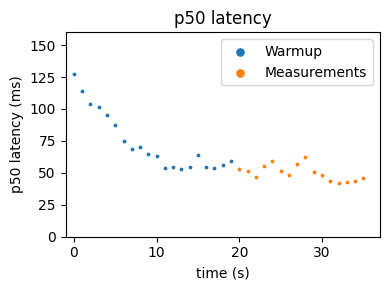

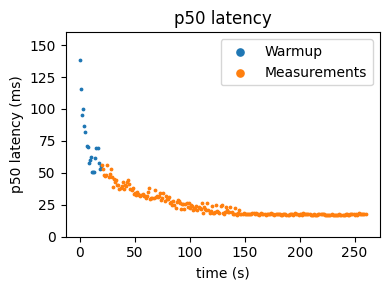

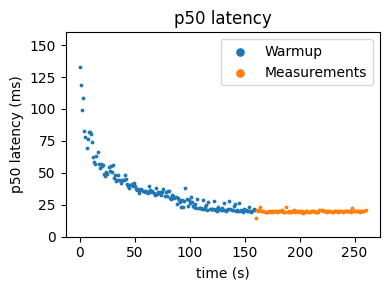

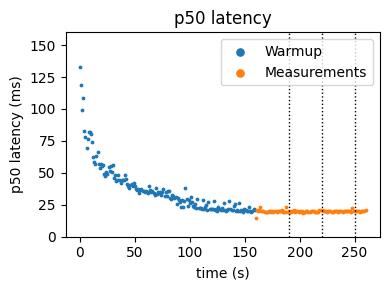

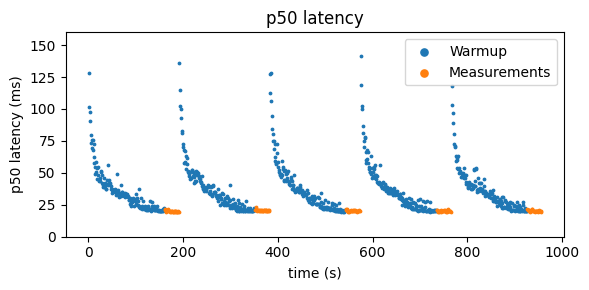

In [367]:
import matplotlib.pyplot as plt

max_width = 6
height = 3

# Find max total datapoints across all experiments for width scaling
max_points = 0
for exp_id, runs in measurements.items():
    total = 0
    run_ids = [r for r in runs.keys() if not r.endswith('-warmup')]
    for run_id in run_ids:
        total += len(runs[run_id])
    warmup_ids = [r for r in runs.keys() if r.endswith('-warmup')]
    for warmup_id in warmup_ids:
        total += len(runs[warmup_id])
    max_points = max(max_points, total)

exp_ids = list(measurements.keys())
for exp_id in exp_ids:
    runs = measurements[exp_id]
    
    # Get run and warmup IDs separately, sorted
    run_ids = sorted([r for r in runs.keys() if not r.endswith('-warmup')])
    warmup_ids = sorted([r for r in runs.keys() if r.endswith('-warmup')])
    
    # Calculate total length for xlim
    total_length = sum(len(runs[r]) for r in run_ids) + sum(len(runs[w]) for w in warmup_ids)
    
    # For experiment 3, generate two plots (with and without dotted lines)
    variants = [(False, '')] if exp_id != 3 else [(False, ''), (True, '-with-dotted-lines')]
    
    for add_lines, suffix in variants:
        # Last experiment uses proportional width, others use fixed 4x3 (4:3 ratio, wider than tall)
        if exp_id == exp_ids[-1]:
            width = max_width * (total_length / max_points)
            fig, ax = plt.subplots(figsize=(width, height))
        else:
            fig, ax = plt.subplots(figsize=(4, 3))
        
        # Plot warmup and run data with different colors
        num_runs = max(len(run_ids), len(warmup_ids))
        x_offset = 0
        warmup_plotted = False
        measurements_plotted = False
        warmup_end_x = 0
        
        for i in range(num_runs):
            if i < len(warmup_ids):
                warmup_values = runs[warmup_ids[i]]
                warmup_values_ms = [v / 1_000_000 for v in warmup_values]
                x = range(x_offset, x_offset + len(warmup_values_ms))
                label = 'Warmup' if not warmup_plotted else None
                ax.scatter(x, warmup_values_ms, s=3, c='C0', label=label)
                warmup_plotted = True
                x_offset += len(warmup_values_ms)
                warmup_end_x = x_offset
            if i < len(run_ids):
                run_values = runs[run_ids[i]]
                run_values_ms = [v / 1_000_000 for v in run_values]
                x = range(x_offset, x_offset + len(run_values_ms))
                label = 'Measurements' if not measurements_plotted else None
                ax.scatter(x, run_values_ms, s=3, c='C1', label=label)
                measurements_plotted = True
                x_offset += len(run_values_ms)
        
        # Add vertical lines at 30, 60, 90 measurement marks for experiment 3 with-dotted-lines variant
        if add_lines:
            for mark in [30, 60, 90]:
                ax.axvline(x=warmup_end_x + mark, color='black', linestyle=':', linewidth=1)
        
        ax.set_title("p50 latency")
        ax.set_xlabel("time (s)")
        ax.set_ylabel("p50 latency (ms)")
        ax.set_ylim(0, 160)
        if exp_id == 1:
            ax.set_xlim(-1, total_length + 1)
        ax.legend(loc='upper right', markerscale=3)
        plt.tight_layout()
        fig.savefig(f"../assets/benchmark-design-experiment-{exp_id}{suffix}.svg")
        plt.show()

In [368]:
import numpy as np

for exp_id in exp_ids:
    runs = measurements[exp_id]
    run_ids = sorted([r for r in runs.keys() if not r.endswith('-warmup')])
    
    print(f"Experiment {exp_id}:")
    all_values = []
    for run_id in run_ids:
        values_ms = np.array(runs[run_id]) / 1_000_000
        mean = np.mean(values_ms)
        std = np.std(values_ms)
        cov = std / mean * 100
        print(f"  {run_id}: mean={mean:.2f}ms, std={std:.2f}ms, CoV={cov:.2f}%")
        all_values.extend(values_ms)
    
    # Merged stats for experiments with multiple runs
    if len(run_ids) > 1:
        all_values = np.array(all_values)
        mean = np.mean(all_values)
        std = np.std(all_values)
        cov = std / mean * 100
        print(f"  [merged]: mean={mean:.2f}ms, std={std:.2f}ms, CoV={cov:.2f}%")
    
    # For experiment 3, show CoV at 30, 60, 90 measurement marks
    if exp_id == 3:
        values_ms = np.array(runs["#1"]) / 1_000_000
        print(f"  --- CoV by measurement count ---")
        for n in [30, 60, 90]:
            if n <= len(values_ms):
                subset = values_ms[:n]
                mean = np.mean(subset)
                std = np.std(subset)
                cov = std / mean * 100
                print(f"  n={n}: CoV={cov:.2f}%")
    
    print()

Experiment 1:
  #1: mean=50.15ms, std=5.92ms, CoV=11.80%

Experiment 2:
  #1: mean=24.00ms, std=9.15ms, CoV=38.14%

Experiment 3:
  #1: mean=20.00ms, std=0.87ms, CoV=4.37%
  --- CoV by measurement count ---
  n=30: CoV=6.95%
  n=60: CoV=5.23%
  n=90: CoV=4.59%

Experiment 4:
  #1: mean=20.08ms, std=0.63ms, CoV=3.16%
  #1-report1-benchmark24: mean=20.63ms, std=0.56ms, CoV=2.72%
  #1-report1-benchmark32: mean=20.31ms, std=0.45ms, CoV=2.23%
  #1-report1-benchmark46: mean=20.19ms, std=0.54ms, CoV=2.66%
  #1-report1-benchmark59: mean=20.26ms, std=0.63ms, CoV=3.11%
  [merged]: mean=20.29ms, std=0.60ms, CoV=2.94%



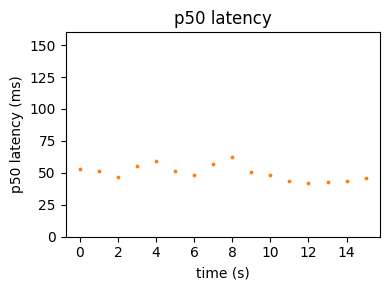

In [369]:
# Experiment 1 measurements only (no warmup)
from matplotlib.ticker import MaxNLocator

runs = measurements[1]
run_ids = sorted([r for r in runs.keys() if not r.endswith('-warmup')])
warmup_ids = sorted([r for r in runs.keys() if r.endswith('-warmup')])

# Calculate total length for consistent xlim
measurements_length = sum(len(runs[r]) for r in run_ids)
total_length = sum(len(runs[w]) for w in warmup_ids) + measurements_length

fig, ax = plt.subplots(figsize=(4, 3))

x_offset = 0
for run_id in run_ids:
    values_ms = [v / 1_000_000 for v in runs[run_id]]
    x = range(x_offset, x_offset + len(values_ms))
    ax.scatter(x, values_ms, s=3, c='C1')
    x_offset += len(values_ms)

ax.set_title("p50 latency")
ax.set_xlabel("time (s)")
ax.set_ylabel("p50 latency (ms)")
ax.set_ylim(0, 160)
# ax.set_xlim(-1, total_length + 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
fig.savefig("../assets/benchmark-design-experiment-1-measurements.svg")
plt.show()

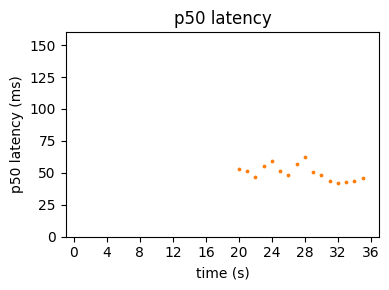

In [370]:
# Experiment 1 measurements only, with gap showing where warmup would be
from matplotlib.ticker import MaxNLocator

runs = measurements[1]
run_ids = sorted([r for r in runs.keys() if not r.endswith('-warmup')])
warmup_ids = sorted([r for r in runs.keys() if r.endswith('-warmup')])

# Calculate lengths
warmup_length = sum(len(runs[w]) for w in warmup_ids)
measurements_length = sum(len(runs[r]) for r in run_ids)
total_length = warmup_length + measurements_length

fig, ax = plt.subplots(figsize=(4, 3))

x_offset = warmup_length
for run_id in run_ids:
    values_ms = [v / 1_000_000 for v in runs[run_id]]
    x = range(x_offset, x_offset + len(values_ms))
    ax.scatter(x, values_ms, s=3, c='C1')
    x_offset += len(values_ms)

ax.set_title("p50 latency")
ax.set_xlabel("time (s)")
ax.set_ylabel("p50 latency (ms)")
ax.set_ylim(0, 160)
ax.set_xlim(-1, total_length + 1)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
fig.savefig("../assets/benchmark-design-experiment-1-measurements-with-gap.svg")
plt.show()

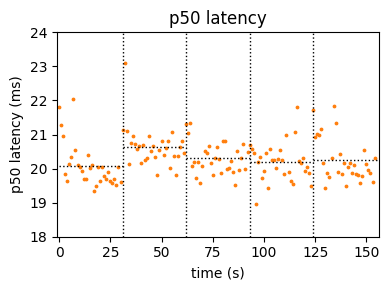

In [371]:
# Experiment 4: measurements only, vertical lines between runs (like Kalibera graph)
runs = measurements[4]
run_ids = sorted([r for r in runs.keys() if not r.endswith('-warmup')])

fig, ax = plt.subplots(figsize=(4, 3))

x_offset = 0
run_boundaries = [0]

for run_id in run_ids:
    values_ms = [v / 1_000_000 for v in runs[run_id]]
    x = range(x_offset, x_offset + len(values_ms))
    ax.scatter(x, values_ms, s=3, c='C1')
    
    # Plot mean as horizontal line for this run
    mean_ms = sum(values_ms) / len(values_ms)
    ax.hlines(y=mean_ms, xmin=x_offset, xmax=x_offset + len(values_ms), color='black', linestyle=':', linewidth=1)
    
    x_offset += len(values_ms)
    run_boundaries.append(x_offset)

# Add vertical dotted lines between runs (except after the last one)
for boundary in run_boundaries[1:-1]:
    ax.axvline(x=boundary, color='black', linestyle=':', linewidth=1)

ax.set_title("p50 latency")
ax.set_xlabel("time (s)")
ax.set_ylabel("p50 latency (ms)")
ax.set_ylim(18, 24)
ax.set_xlim(-1, x_offset + 1)
plt.tight_layout()
fig.savefig("../assets/benchmark-design-experiment-4-random-initial-state.svg")
plt.show()